In [2]:
!pip install mlflow

   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   --- ------------------------------------ 1.0/10.6 MB 5.2 MB/s eta 0:00:02
   -------- ------------------------------- 2.4/10.6 MB 5.8 MB/s eta 0:00:02
   ------------ --------------------------- 3.4/10.6 MB 5.6 MB/s eta 0:00:02
   ----------------- ---------------------- 4.7/10.6 MB 5.7 MB/s eta 0:00:02
   ------------------- -------------------- 5.2/10.6 MB 5.5 MB/s eta 0:00:01
   ------------------------- -------------- 6.8/10.6 MB 5.4 MB/s eta 0:00:01
   ------------------------------ --------- 8.1/10.6 MB 5.4 MB/s eta 0:00:01
   ----------------------------------- ---- 9.4/10.6 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------  10.5/10.6 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 10.6/10.6 MB 4.9 MB/s  0:00:02
   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   ------------ --------------------------- 1.0/3.3 MB 6.0 MB/s eta 0:00:01
   -------------

In [1]:
# ===== CELL 1: Prepare features for clustering =====
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import mlflow

rfm = pd.read_csv("data/processed/rfm_features.csv")
features = ['Recency','Frequency','Monetary','AOV','UniqueProducts','UniqueCategories','Tenure']
X = np.log1p(rfm[features])
X_scaled = StandardScaler().fit_transform(X)
print(f"Feature matrix: {X_scaled.shape}")

ModuleNotFoundError: No module named 'mlflow'

In [3]:
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

rfm = pd.read_csv("data/processed/rfm_features.csv")

features = ['Recency','Frequency','Monetary','AOV',
            'UniqueProducts','UniqueCategories','Tenure']

X = np.log1p(rfm[features])

X_scaled = StandardScaler().fit_transform(X)

print(f"Feature matrix: {X_scaled.shape}")

Feature matrix: (7571, 7)


Best K = 3  (silhouette = 0.493)


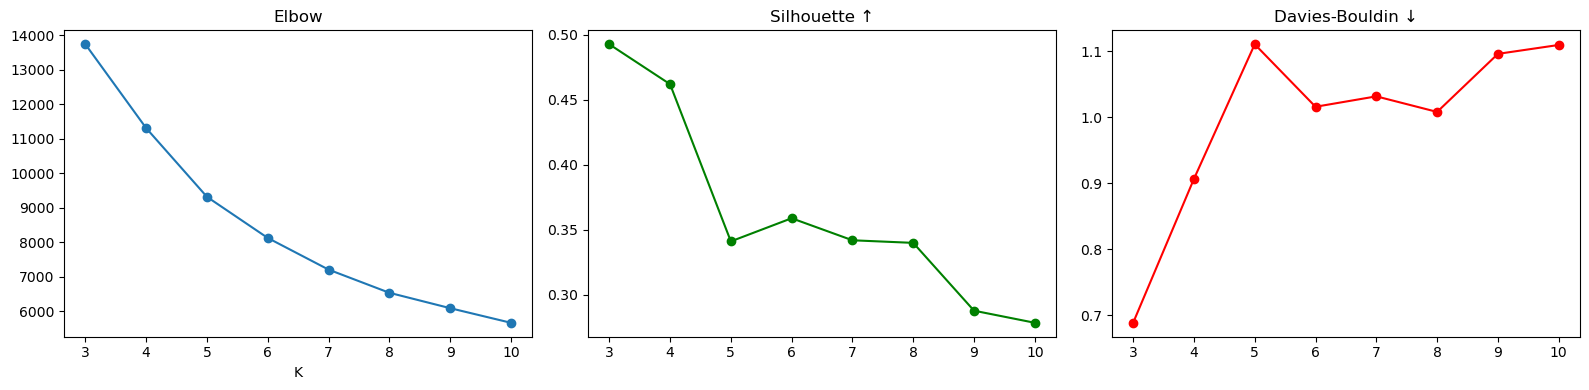

In [4]:
inertias, silhouettes, db_scores = [], [], []

K_range = range(3, 11)

for k in K_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    ).fit(X_scaled)

    # Elbow metric
    inertias.append(km.inertia_)

    # Silhouette score
    sil = silhouette_score(
        X_scaled,
        km.labels_,
        sample_size=5000,
        random_state=42
    )

    # Davies-Bouldin score
    db = davies_bouldin_score(X_scaled, km.labels_)

    silhouettes.append(sil)
    db_scores.append(db)

# Best K
best_k = K_range[np.argmax(silhouettes)]

print(f"Best K = {best_k}  (silhouette = {max(silhouettes):.3f})")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Elbow
axes[0].plot(K_range, inertias, 'o-')
axes[0].set_title('Elbow')
axes[0].set_xlabel('K')

# Silhouette
axes[1].plot(K_range, silhouettes, 'o-', color='green')
axes[1].set_title('Silhouette ↑')

# Davies-Bouldin
axes[2].plot(K_range, db_scores, 'o-', color='red')
axes[2].set_title('Davies-Bouldin ↓')

plt.tight_layout()
plt.savefig('reports/day3_kmeans_search.png', dpi=120)

plt.show()

In [5]:
# Final KMeans model
km_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
).fit(X_scaled)

# Add cluster labels
rfm['Segment_KMeans'] = km_final.labels_

# Final silhouette score
final_sil = silhouette_score(
    X_scaled,
    km_final.labels_,
    sample_size=5000
)

print(f"Final KMeans silhouette score: {final_sil:.3f}")

# DBSCAN for anomaly/VIP detection
db = DBSCAN(
    eps=0.6,
    min_samples=20
).fit(X_scaled)

rfm['Segment_DBSCAN'] = db.labels_

# Count outliers
n_outliers = (db.labels_ == -1).sum()

print(f"DBSCAN outliers (potential VIP/anomaly): {n_outliers}")

Final KMeans silhouette score: 0.492
DBSCAN outliers (potential VIP/anomaly): 264


In [6]:
# ===== CELL 4: Business interpretation =====
profile = rfm.groupby('Segment_KMeans').agg(
    n           =('CustomerID','count'),
    Recency_avg =('Recency','mean'),
    Freq_avg    =('Frequency','mean'),
    Monetary_avg=('Monetary','mean'),
    AOV_avg     =('AOV','mean'),
    Tenure_avg  =('Tenure','mean'),
).round(1)
print(profile)

# Auto-label segments based on RFM profile
def label_segment(row):
    if row['Recency_avg'] < 30 and row['Freq_avg'] > 15 and row['Monetary_avg'] > 1500:
        return "🏆 Champions"
    if row['Recency_avg'] < 60 and row['Freq_avg'] > 8:
        return "💛 Loyal Customers"
    if row['Recency_avg'] < 45 and row['Freq_avg'] <= 3:
        return "🌱 New Customers"
    if row['Recency_avg'] < 90 and row['Freq_avg'] > 4:
        return "🚀 Potential Loyalists"
    if row['Recency_avg'] > 120 and row['Freq_avg'] > 5:
        return "⚠️ At Risk"
    return "💤 Hibernating"

profile['Persona'] = profile.apply(label_segment, axis=1)
print(profile[['n','Persona']])

# Save
seg_map = profile['Persona'].to_dict()
rfm['Persona'] = rfm['Segment_KMeans'].map(seg_map)
rfm.to_csv("data/processed/customer_segments.csv", index=False)

                   n  Recency_avg  Freq_avg  Monetary_avg  AOV_avg  Tenure_avg
Segment_KMeans                                                                
0               1626        423.2       1.3         241.8    130.5        18.7
1               1607         13.7      29.8       27295.6    194.9       485.4
2               4338        141.4       8.7        4413.7    204.8       327.8
                   n        Persona
Segment_KMeans                     
0               1626  💤 Hibernating
1               1607    🏆 Champions
2               4338     ⚠️ At Risk
